# ManiSkill

## Setup

In [3]:
import sys
import os
from pathlib import Path
import random
import urllib.request
from collections import defaultdict
import time
import datetime
import collections
# from dataclasses import field #, dataclass

# import xarray as xr
from tqdm import tqdm
from IPython.display import Video
import numpy as np
import torch
from torch.utils.data.dataset import Dataset
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.sampler import RandomSampler, BatchSampler
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from diffusers.optimization import get_scheduler
from diffusers.training_utils import EMAModel

import mani_skill
from mani_skill.trajectory.dataset import ManiSkillTrajectoryDataset

/home/kir0ul/pixi_ws/sdl/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kir0ul/pixi_ws/sdl/.pixi/envs/default/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1750199048837/work/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [5]:
# setting device on GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print("Using device:", device)
print()
# Additional Info when using cuda
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))
    print("Memory Usage:")
    print("Allocated:", round(torch.cuda.memory_allocated(0) / 1024**3, 1), "GB")
    print("Cached:   ", round(torch.cuda.memory_reserved(0) / 1024**3, 1), "GB")
    print(torch.cuda.memory_summary())

Using device: cpu



In [6]:
# Reproducibility
seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [7]:
repo_path = "diffusion_policy"
if repo_path not in sys.path:
    sys.path.append(repo_path)

print("sys.path:\n")
for elem in sys.path:
    print(elem)

sys.path:


/opt/ros/noetic/lib/python3/dist-packages
/home/kir0ul/pixi_ws/sdl/.pixi/envs/default/lib/python312.zip
/home/kir0ul/pixi_ws/sdl/.pixi/envs/default/lib/python3.12
/home/kir0ul/pixi_ws/sdl/.pixi/envs/default/lib/python3.12/lib-dynload
/home/kir0ul/pixi_ws/sdl/.pixi/envs/default/lib/python3.12/site-packages
/tmp/tmpn4m6rgl_
diffusion_policy


## Demonstrations data

In [8]:
# from diffusion_policy import diffusion_policy
# from diffusion_policy.train import SmallDemoDataset_DiffusionPolicy
from diffusion_policy.utils import IterationBasedBatchSampler, worker_init_fn
from diffusion_policy.conditional_unet1d import ConditionalUnet1D

# from diffusion_policy.make_env import make_eval_envs
from diffusion_policy.evaluate import evaluate
# from diffusion_policy.utils import load_demo_dataset

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.interpolate import make_splrep

# from segmentation_utils import (
#     read_h5_data,
#     ts2df,
# )
import h5py

In [10]:
def plot_xyzgrip(traj, time_type="timesteps", fname=None):
    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(
            nrows=len(traj.columns) - 1,
            ncols=1,
            sharex=True,  # figsize=(8, 5)
        )
        # cmap = mpl.colormaps.get("tab10").colors
        jdx = 0
        for idx, axi in enumerate(range(len(traj.columns))):
            if traj.columns[idx] == "timestamp":
                continue
            ax[jdx].plot(
                traj.timestamp, traj[traj.columns[idx]], color="k"
            )  # cmap[idx])
            ax[jdx].set_ylabel(traj.columns[idx])
            # if supervised_samples is not None:
            #     ax[jdx].scatter(
            #         traj.timestamp, supervised_samples[:, idx]#, color="k"
            #     )  # cmap[idx])
            jdx += 1
        ax[-1].set_xlabel("Time")
        # ax.legend(loc="best")
        # axi.legend(bbox_to_anchor=(1.0, 1.02))
        if time_type == "timesteps":
            fig.autofmt_xdate()
        fig.tight_layout()
        if fname is not None:
            fig.savefig(fname)
        plt.show()

In [11]:
def resample_df(df, nb_points=256, smoothing_factor=0):
    new_index = np.linspace(start=df.index.start, stop=df.index.stop, num=nb_points)
    for idx, col in enumerate(df.columns):
        if idx == 0:
            df_smooth = pd.DataFrame(
                {
                    col: make_splrep(x=df.index, y=df[col], s=smoothing_factor)(
                        new_index
                    ),
                }
            )
        else:
            df_smooth[col] = make_splrep(df.index, df[col], s=smoothing_factor)(
                new_index
            )
    return df_smooth

In [44]:
 def resample_arr(arr, nb_points=256):
    index_ori = np.arange(start=0, stop=arr.shape[0])
    new_index = np.linspace(start=0, stop=arr.shape[0], num=nb_points)
    arr_smooth = make_splrep(x=X_filtered.index, y=y_filtered)(new_index)
    return arr_smooth

In [12]:
def read_h5_data(fname):
    hf = h5py.File(fname, "r")
    print(f"Keys in `{fname}`: {list(hf.keys())}")
    js = hf.get("joint_state_info")
    joint_time = np.array(js.get("joint_time"))
    joint_pos = np.array(js.get("joint_positions"))
    joint_vel = np.array(js.get("joint_velocities"))
    joint_eff = np.array(js.get("joint_effort"))
    joint_data = [joint_time, joint_pos, joint_vel, joint_eff]

    tf = hf.get("transform_info")
    tf_time = np.array(tf.get("transform_time"))
    tf_pos = np.array(tf.get("transform_positions"))
    tf_rot = np.array(tf.get("transform_orientations"))
    tf_data = [tf_time, tf_pos, tf_rot]
    # print(tf_pos)

    wr = hf.get("wrench_info")
    wrench_time = np.array(wr.get("wrench_time"))
    wrench_frc = np.array(wr.get("wrench_force"))
    wrench_trq = np.array(wr.get("wrench_torque"))
    wrench_data = [wrench_time, wrench_frc, wrench_trq]

    gp = hf.get("gripper_info")
    gripper_time = np.array(gp.get("gripper_time"))
    gripper_pos = np.array(gp.get("gripper_position"))
    # gripper_time = []
    # gripper_pos = []
    gripper_data = [gripper_time, gripper_pos]

    hf.close()

    return joint_data, tf_data, wrench_data, gripper_data

In [13]:
def conv2timestamps(tarray):
    # nanosec_conv = 1e-9
    time_sec = tarray[:, 0]
    time_nanosec = tarray[:, 1]
    # time = time_sec + time_nanosec * nanosec_conv

    timestamps = []
    for t_idx, t_val in enumerate(time_sec):
        timestamp = pd.Timestamp(time_sec[t_idx], unit="s", tz="EST") + pd.to_timedelta(
            time_nanosec[t_idx], unit="ns"
        )
        timestamps.append(timestamp)
    timestamps = pd.Series(timestamps)
    return timestamps

In [14]:
def xyzgrip2df(tf_data, gripper_data):
    # ts_time = tf_data[0][:, 0] + tf_data[0][:, 1] * (10.0**-9)

    tf_df = pd.DataFrame(
        {
            "pos_x": tf_data[1][:, 0],
            "pos_y": tf_data[1][:, 1],
            "pos_z": tf_data[1][:, 2],
            "timestamp": conv2timestamps(tf_data[0]),
        }
    )

    gripper_df = pd.DataFrame(
        {
            "val": gripper_data[1].squeeze(),
            "timestamp": conv2timestamps(gripper_data[0]),
        }
    )
    gripper_df["val"] = gripper_df["val"].apply(lambda elem: elem / 100)

    # Merge both DataFrames into one
    traj = pd.merge_asof(tf_df, gripper_df, on="timestamp")
    traj.dropna(inplace=True, ignore_index=True)
    traj.rename(columns={"val": "gripper"}, inplace=True)
    return traj

In [15]:
def joints2df(joint_data):
    # ts_time = tf_data[0][:, 0] + tf_data[0][:, 1] * (10.0**-9)
    # joints_ds = xr.Dataset(
    #     dict(
    #         time=("timestamps", conv2timestamps(joint_data[0])),
    #         pos=(["index", "joints"], joint_data[1]),
    #         vel=(["index", "joints"], joint_data[2]),
    #         eff=(["index", "joints"], joint_data[3])
    #         )
    #     )
    df = pd.DataFrame(
        {
            "timestamp": conv2timestamps(joint_data[0]),
        }
    )
    data_labels = ["pos", "vel", "eff"]
    for idx, mat in enumerate(joint_data[1:]):
        for jdx in range(mat.shape[1]):
            df[f"{data_labels[idx]}_{jdx}"] = mat[:, jdx]

    return df

In [16]:
def plot_joints(df):
    labels = np.unique([lab[:-2] for lab in df.drop(columns=["timestamp"]).columns])
    with plt.style.context("ggplot"):
        fig, ax = plt.subplots(
            nrows=len(labels),
            ncols=1,
            sharex=True,  # figsize=(8, 5)
        )
        # cmap = mpl.colormaps.get("tab10").colors
        for idx, col_name in enumerate(df.columns):
            if col_name == "timestamp":
                continue
            for jdx in range(len(labels)):
                if labels[jdx] in col_name:
                    ax[jdx].plot(
                        df.timestamp,
                        df[col_name],  # , color="k"
                    )  # cmap[idx])
                    ax[jdx].set_ylabel(labels[jdx])
        ax[-1].set_xlabel("Time")
        # ax.legend(loc="best")
        # axi.legend(bbox_to_anchor=(1.0, 1.02))
        fig.autofmt_xdate()
        fig.tight_layout()
        plt.show()

In [17]:
filenames = [Path("long-task-1.h5"), Path("long-task-2.h5")]
for filename in filenames:
    assert filename.exists(), f"File doesn't exist: {filename}"

In [71]:
seq_length = 2**10
# seq_length = 2**7
print(f"Resampling to {seq_length} points")

Resampling to 1024 points


Keys in `long-task-1.h5`: ['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']


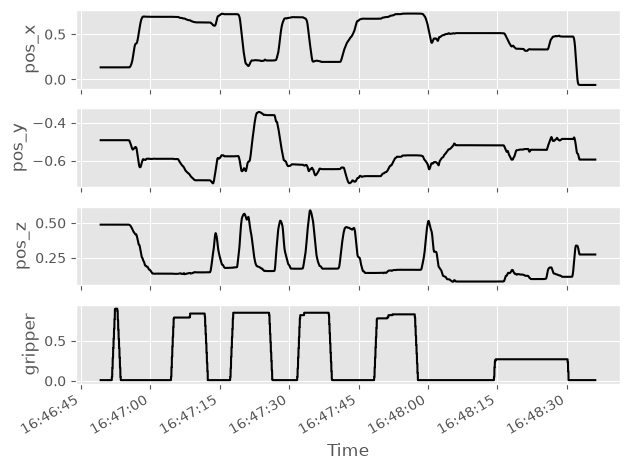

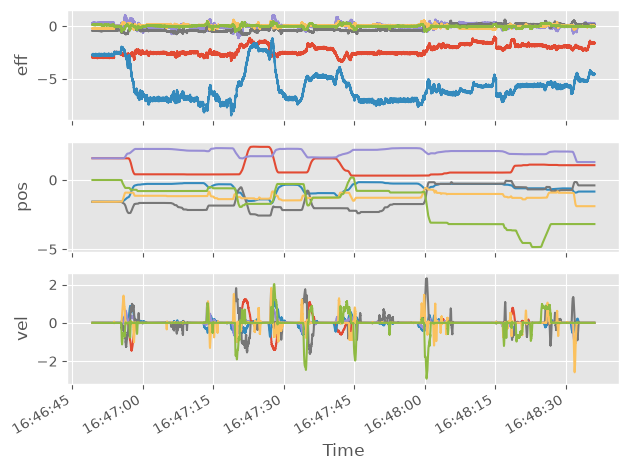

Keys in `long-task-2.h5`: ['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']


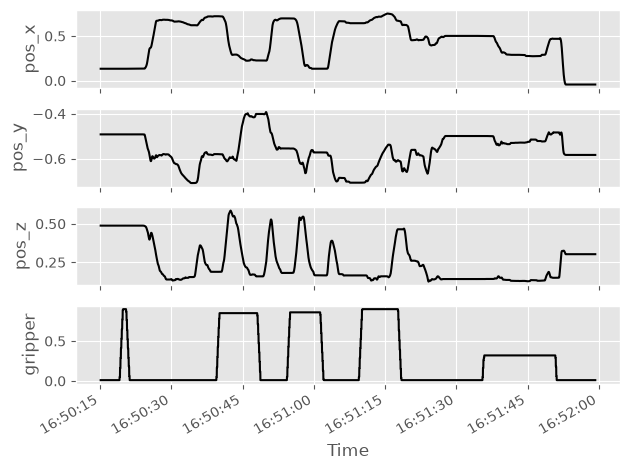

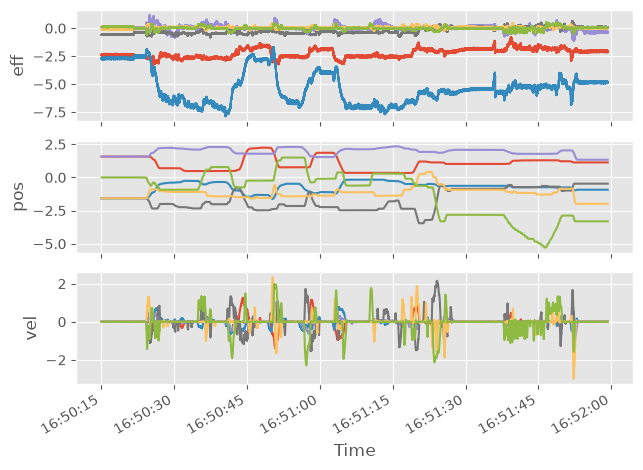

In [72]:
actions = []
observations = []
for file_i, file_val in enumerate(filenames):
    # hdf5_path = data_path_root / hdf5_file
    joint_data, tf_data, wrench_data, gripper_data = read_h5_data(fname=file_val)
    traj = xyzgrip2df(tf_data=tf_data, gripper_data=gripper_data)
    plot_xyzgrip(traj=traj, fname=f"{str(file_val)[:-3]}.png")
    # traj_down, minmaxscaler, traj_down_scaled = preprocessing(
    #     traj=traj, resample_num=seq_length
    # )  # <--- Q: Scale or not scale?
    traj_float = traj.drop(columns=["timestamp"])
    traj_down = resample_df(df=traj_float, nb_points=seq_length)
    joints_df = joints2df(joint_data)
    plot_joints(joints_df)
    joints_float = joints_df.drop(columns=["timestamp"])
    joints_down = resample_df(df=joints_float, nb_points=seq_length + 1)

    actions.append(traj_down.to_numpy())
    observations.append(joints_down.to_numpy())
trajectories = {
    "observations": observations,
    "actions": actions,
}

In [73]:
joint_data[2].shape, wrench_data[2].shape

((51634, 6), (51634, 3))

### Hyperparameters

In [74]:
batch_size = 1024  # the batch size of sample from the replay memory
# batch_size = 32 # the batch size of sample from the replay memory
total_iters = 100_000  # total timesteps of the experiment
# total_iters = 100 # total timesteps of the experiment
# capture_video = False # whether to capture videos of the agent performances (check out `videos` folder)

# Diffusion Policy specific arguments
obs_horizon = 2  # Seems not very important in ManiSkill, 1, 2, 4 work well
act_horizon = 8  # Seems not very important in ManiSkill, 4, 8, 15 work well
pred_horizon = 16  # 16->8 leads to worse performance, maybe it is like generate a half image; 16->32, improvement is very marginal
lr = 1e-4  # the learning rate of the diffusion policy
# diffusion_step_embed_dim = 64 # not very important
diffusion_step_embed_dim = 2**6  # not very important
print(f"diffusion_step_embed_dim: {diffusion_step_embed_dim}")
# unet_dims = field(default_factory=lambda: [64, 128, 256]) # default setting is about ~4.5M params
unet_dims = [64, 128, 256]  # default setting is about ~4.5M params
# unet_dims = [2**6, 2**7, 2**8] # default setting is about ~4.5M params
# unet_dims = [2**4, 2**5, 2**6] # default setting is about ~4.5M params
print(f"unet_dims: {unet_dims}")
n_groups = 8  # jigu says it is better to let each group have at least 8 channels; it seems 4 and 8 are simila

# Environment/experiment specific arguments
num_dataload_workers = 0  # the number of workers to use for loading the training data in the torch dataloader
save_freq = 20  # the frequency of saving the model checkpoints. By default this is None and will only save checkpoints based on the best evaluation metrics.
log_freq = 1000  # the frequency of logging the training metrics

# max_episode_steps = 200 #"""Change the environments' max_episode_steps to this value. Sometimes necessary if the demonstrations being imitated are too short. Typically the default max episode steps of environments in ManiSkill are tuned lower so reinforcement learning agents can learn faster."""
# num_eval_envs = 10 # the number of parallel environments to evaluate the agent on
# eval_freq = 5000 # the frequency of evaluating the agent on the evaluation environments

diffusion_step_embed_dim: 64
unet_dims: [64, 128, 256]


In [75]:
# exp_name = os.path.basename(__name__)#[: -len(".py")]
# run_name = f"{env_id}__{exp_name}__{seed}__{int(time.time())}"
run_name = f"long-task__{seed}__{datetime.datetime.now().isoformat()}"
run_name

'long-task__1__2026-07-24T17:43:03.683662'

### DataLoader

In [76]:
# trajectories = load_demo_dataset(data_path, num_traj=demos, concat=False)
print(trajectories.keys())
print(trajectories["observations"][0].shape)
obs_dim = trajectories["observations"][0].shape[-1]
act_dim = trajectories["actions"][0].shape[-1]
print(f"obs_dim: {obs_dim}")
print(f"act_dim: {act_dim}")

dict_keys(['observations', 'actions'])
(1025, 18)
obs_dim: 18
act_dim: 4


In [77]:
# normalize data
def get_data_stats(data):
    data = data.reshape(-1, data.shape[-1]).cpu().numpy()
    stats = {"min": np.min(data, axis=0), "max": np.max(data, axis=0)}
    return stats


def normalize_data(data, stats):
    denominator = stats["max"] - stats["min"]
    denominator[denominator == 0] = 1.0  # Prevent division by zero
    # normalize to [0, 1]
    ndata = (data.cpu().numpy() - stats["min"]) / denominator
    # normalize to [-1, 1]
    ndata = ndata * 2 - 1
    return torch.tensor(ndata)


def unnormalize_data(ndata, stats):
    ndata = (ndata + 1) / 2
    data = ndata * (stats["max"] - stats["min"]) + stats["min"]
    return data

In [78]:
class DemoDataset(Dataset):  # Load everything into GPU memory
    def __init__(self, trajectories, device, num_traj, obs_horizon, pred_horizon):
        # if data_path[-4:] == '.pkl':
        #     raise NotImplementedError()
        # else:
        #     from diffusion_policy.utils import load_demo_dataset
        #     trajectories = load_demo_dataset(data_path, num_traj=num_traj, concat=False)
        #     # trajectories['observations'] is a list of np.ndarray (L+1, obs_dim)
        #     # trajectories['actions'] is a list of np.ndarray (L, act_dim)

        for k, v in trajectories.items():
            for i in range(len(v)):
                trajectories[k][i] = torch.Tensor(v[i]).to(device)

        # # Pre-compute all possible (traj_idx, start, end) tuples, this is very specific to Diffusion Policy
        # if 'delta_pos' in control_mode or control_mode == 'base_pd_joint_vel_arm_pd_joint_vel':
        # self.pad_action_arm = torch.zeros((trajectories['actions'][0].shape[1]-1,), device=device)
        #     # to make the arm stay still, we pad the action with 0 in 'delta_pos' control mode
        #     # gripper action needs to be copied from the last action
        # # else:
        # #     raise NotImplementedError(f'Control Mode {args.control_mode} not supported')
        # self.obs_horizon, self.pred_horizon = obs_horizon, pred_horizon = obs_horizon, pred_horizon
        self.slices = []
        num_traj = len(trajectories["actions"])
        total_transitions = 0
        for traj_idx in range(num_traj):
            L = trajectories["actions"][traj_idx].shape[0]
            assert trajectories["observations"][traj_idx].shape[0] == L + 1
            total_transitions += L

            # |o|o|                             observations: 2
            # | |a|a|a|a|a|a|a|a|               actions executed: 8
            # |p|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p| actions predicted: 16
            pad_before = obs_horizon - 1
            # Pad before the trajectory, so the first action of an episode is in "actions executed"
            # obs_horizon - 1 is the number of "not used actions"
            pad_after = pred_horizon - obs_horizon
            # Pad after the trajectory, so all the observations are utilized in training
            # Note that in the original code, pad_after = act_horizon - 1, but I think this is not the best choice
            self.slices += [
                (traj_idx, start, start + pred_horizon)
                for start in range(-pad_before, L - pred_horizon + pad_after)
            ]  # slice indices follow convention [start, end)

        print(
            f"Total transitions: {total_transitions}, Total obs sequences: {len(self.slices)}"
        )

        self.trajectories = trajectories

        # compute statistics and normalized data to [-1,1]
        stats = dict()
        normalized_train_data = dict()
        all_obs = torch.concatenate(trajectories["observations"], axis=0)
        all_actions = torch.concatenate(trajectories["actions"], axis=0)
        stats["observations"] = get_data_stats(all_obs)
        stats["actions"] = get_data_stats(all_actions)

        for key, data in self.trajectories.items():
            for idx in range(len(data)):
                data_curr = data[idx]
                if idx == 0:
                    normalized_train_data[key] = []
                normalized_train_data[key].append(normalize_data(data_curr, stats[key]))
        self.stats = stats
        self.normalized_train_data = normalized_train_data

        self.pred_horizon = pred_horizon
        # self.action_horizon = action_horizon
        self.obs_horizon = obs_horizon

    def __getitem__(self, index):
        traj_idx, start, end = self.slices[index]
        L, act_dim = self.trajectories["actions"][traj_idx].shape

        # obs_seq = self.trajectories['observations'][traj_idx][max(0, start):start+self.obs_horizon]
        obs_seq = self.normalized_train_data["observations"][traj_idx][
            max(0, start) : start + self.obs_horizon
        ]
        # start+self.obs_horizon is at least 1
        # act_seq = self.trajectories['actions'][traj_idx][max(0, start):end]
        act_seq = self.normalized_train_data["actions"][traj_idx][max(0, start) : end]

        if start < 0:  # pad before the trajectory
            obs_seq = torch.cat([obs_seq[0].repeat(-start, 1), obs_seq], dim=0)
            act_seq = torch.cat([act_seq[0].repeat(-start, 1), act_seq], dim=0)
        if end > L:  # pad after the trajectory
            # hold the last real action (pos_x, pos_y, pos_z, gripper) so the
            # commanded end-effector position doesn't jump to the origin
            pad_action = act_seq[-1]
            act_seq = torch.cat([act_seq, pad_action.repeat(end - L, 1)], dim=0)
            # gripper_action = act_seq[-1, -1]
            # pad_action = torch.cat((self.pad_action_arm, gripper_action[None]), dim=0)
            # act_seq = torch.cat([act_seq, pad_action.repeat(end-L, 1)], dim=0)
            # making the robot (arm and gripper) stay still
        assert (
            obs_seq.shape[0] == self.obs_horizon
            and act_seq.shape[0] == self.pred_horizon
        ), (
            f"obs_seq: {obs_seq.shape} != obs_horizon ({self.obs_horizon}), act_seq: {act_seq.shape} != pred_horizon ({self.pred_horizon})"
        )
        return {
            "observations": obs_seq,
            "actions": act_seq,
        }

    def __len__(self):
        return len(self.slices)

In [79]:
demos = len(trajectories["observations"])
assert len(trajectories["observations"]) == len(trajectories["actions"]), (
    "Actions and Observations must have the same length"
)

# dataloader setup
dataset = DemoDataset(
    trajectories=trajectories,
    device=device,
    num_traj=demos,
    obs_horizon=obs_horizon,
    pred_horizon=pred_horizon,
)
sampler = RandomSampler(dataset, replacement=False)
batch_sampler = BatchSampler(sampler, batch_size=batch_size, drop_last=True)
batch_sampler = IterationBasedBatchSampler(batch_sampler, total_iters)
train_dataloader = DataLoader(
    dataset,
    batch_sampler=batch_sampler,
    num_workers=num_dataload_workers,
    worker_init_fn=lambda worker_id: worker_init_fn(worker_id, base_seed=seed),
)

Total transitions: 2048, Total obs sequences: 2046


## Training

In [80]:
writer = SummaryWriter(f"runs/{run_name}")
# writer.add_text(
#     "hyperparameters",
#     "|param|value|\n|-|-|\n%s" % ("\n".join([f"|{key}|{value}|" for key, value in vars(args).items()])),
# )

### Model

In [81]:
class Agent(nn.Module):
    def __init__(
        self,
        obs_horizon,
        act_horizon,
        pred_horizon,
        unet_dims,
        diffusion_step_embed_dim,
        obs_dim,
        act_dim,
    ):
        super().__init__()
        self.obs_horizon = obs_horizon
        self.act_horizon = act_horizon
        self.pred_horizon = pred_horizon
        # assert len(env.single_observation_space.shape) == 2 # (obs_horizon, obs_dim)
        # assert len(env.single_action_space.shape) == 1 # (act_dim, )
        # assert (env.single_action_space.high == 1).all() and (env.single_action_space.low == -1).all()
        # denoising results will be clipped to [-1,1], so the action should be in [-1,1] as well
        # self.act_dim = env.single_action_space.shape[0]
        self.act_dim = act_dim

        self.noise_pred_net = ConditionalUnet1D(
            input_dim=self.act_dim,  # act_horizon is not used (U-Net doesn't care)
            # global_cond_dim=np.prod(env.single_observation_space.shape), # obs_horizon * obs_dim
            global_cond_dim=obs_horizon * obs_dim,  # obs_horizon * obs_dim
            diffusion_step_embed_dim=diffusion_step_embed_dim,
            down_dims=unet_dims,
            n_groups=n_groups,
        )
        self.num_diffusion_iters = 100
        self.noise_scheduler = DDPMScheduler(
            num_train_timesteps=self.num_diffusion_iters,
            beta_schedule="squaredcos_cap_v2",  # has big impact on performance, try not to change
            clip_sample=True,  # clip output to [-1,1] to improve stability
            prediction_type="epsilon",  # predict noise (instead of denoised action)
        )

    def compute_loss(self, obs_seq, action_seq):
        B = obs_seq.shape[0]

        # observation as FiLM conditioning
        obs_cond = obs_seq.flatten(start_dim=1)  # (B, obs_horizon * obs_dim)

        # sample noise to add to actions
        noise = torch.randn((B, self.pred_horizon, self.act_dim), device=device)

        # sample a diffusion iteration for each data point
        timesteps = torch.randint(
            0, self.noise_scheduler.config.num_train_timesteps, (B,), device=device
        ).long()

        # add noise to the clean images(actions) according to the noise magnitude at each diffusion iteration
        # (this is the forward diffusion process)
        noisy_action_seq = self.noise_scheduler.add_noise(action_seq, noise, timesteps)

        # predict the noise residual
        noise_pred = self.noise_pred_net(
            noisy_action_seq, timesteps, global_cond=obs_cond
        )

        return F.mse_loss(noise_pred, noise)

    def get_action(self, obs_seq):
        # init scheduler
        # self.noise_scheduler.set_timesteps(self.num_diffusion_iters)
        # set_timesteps will change noise_scheduler.timesteps is only used in noise_scheduler.step()
        # noise_scheduler.step() is only called during inference
        # if we use DDPM, and inference_diffusion_steps == train_diffusion_steps, then we can skip this

        # obs_seq: (B, obs_horizon, obs_dim)
        B = obs_seq.shape[0]
        with torch.no_grad():
            obs_cond = obs_seq.flatten(start_dim=1)  # (B, obs_horizon * obs_dim)

            # initialize action from Guassian noise
            noisy_action_seq = torch.randn(
                (B, self.pred_horizon, self.act_dim), device=obs_seq.device
            )

            for k in self.noise_scheduler.timesteps:
                # predict noise
                noise_pred = self.noise_pred_net(
                    sample=noisy_action_seq,
                    timestep=k,
                    global_cond=obs_cond,
                )

                # inverse diffusion step (remove noise)
                noisy_action_seq = self.noise_scheduler.step(
                    model_output=noise_pred,
                    timestep=k,
                    sample=noisy_action_seq,
                ).prev_sample

        # only take act_horizon number of actions
        start = self.obs_horizon - 1
        end = start + self.act_horizon
        return noisy_action_seq[:, start:end]  # (B, act_horizon, act_dim)

In [82]:
# # env setup
# env_kwargs = dict(
#     control_mode=control_mode,
#     reward_mode="sparse",
#     obs_mode="state",
#     render_mode="rgb_array",
#     human_render_camera_configs=dict(shader_pack="default")
#     )
# assert max_episode_steps != None, "max_episode_steps must be specified as imitation learning algorithms task solve speed is dependent on the data you train on"
# env_kwargs["max_episode_steps"] = max_episode_steps
# other_kwargs = dict(obs_horizon=obs_horizon)
# envs = make_eval_envs(
#     env_id,
#     num_eval_envs,
#     sim_backend,
#     env_kwargs,
#     other_kwargs,
#     video_dir=f'runs/{run_name}/videos' if capture_video else None
#     )


# agent setup
agent = Agent(
    obs_horizon=obs_horizon,
    act_horizon=act_horizon,
    pred_horizon=pred_horizon,
    unet_dims=unet_dims,
    diffusion_step_embed_dim=diffusion_step_embed_dim,
    obs_dim=obs_dim,
    act_dim=act_dim,
).to(device)
optimizer = optim.AdamW(
    params=agent.parameters(), lr=lr, betas=(0.95, 0.999), weight_decay=1e-6
)

# Cosine LR schedule with linear warmup
lr_scheduler = get_scheduler(
    name="cosine",
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=total_iters,
)

# Exponential Moving Average
# accelerates training and improves stability
# holds a copy of the model weights
ema = EMAModel(parameters=agent.parameters(), power=0.75)
ema_agent = Agent(
    obs_horizon=obs_horizon,
    act_horizon=act_horizon,
    pred_horizon=pred_horizon,
    unet_dims=unet_dims,
    diffusion_step_embed_dim=diffusion_step_embed_dim,
    obs_dim=obs_dim,
    act_dim=act_dim,
).to(device)

# best_eval_metrics = defaultdict(float)
timings = defaultdict(float)

number of parameters: 4.22M
number of parameters: 4.22M


### Utils

In [83]:
def save_ckpt(run_name, tag):
    os.makedirs(f"runs/{run_name}/checkpoints", exist_ok=True)
    ema.copy_to(ema_agent.parameters())
    torch.save(
        {
            "agent": agent.state_dict(),
            "ema_agent": ema_agent.state_dict(),
        },
        f"runs/{run_name}/checkpoints/{tag}.pt",
    )


# # define evaluation and logging functions
# def evaluate_and_save_best(iteration):
#     if iteration % eval_freq == 0:
#         last_tick = time.time()
#         ema.copy_to(ema_agent.parameters())
#         eval_metrics = evaluate(
#             num_eval_episodes, ema_agent, envs, device, sim_backend
#         )
#         timings["eval"] += time.time() - last_tick

#         print(f"Evaluated {len(eval_metrics['success_at_end'])} episodes")
#         for k in eval_metrics.keys():
#             eval_metrics[k] = np.mean(eval_metrics[k])
#             writer.add_scalar(f"eval/{k}", eval_metrics[k], iteration)
#             print(f"{k}: {eval_metrics[k]:.4f}")

#         save_on_best_metrics = ["success_once", "success_at_end"]
#         for k in save_on_best_metrics:
#             if k in eval_metrics and eval_metrics[k] > best_eval_metrics[k]:
#                 best_eval_metrics[k] = eval_metrics[k]
#                 save_ckpt(run_name, f"best_eval_{k}")
#                 print(
#                     f"New best {k}_rate: {eval_metrics[k]:.4f}. Saving checkpoint."
#                 )


def log_metrics(iteration):
    if iteration % log_freq == 0:
        writer.add_scalar(
            "charts/learning_rate", optimizer.param_groups[0]["lr"], iteration
        )
        writer.add_scalar("losses/total_loss", total_loss.item(), iteration)
        for k, v in timings.items():
            writer.add_scalar(f"time/{k}", v, iteration)

### Training loop

In [84]:
# agent.train()
# pbar = tqdm(total=total_iters)
# last_tick = time.time()
# for iteration, data_batch in enumerate(train_dataloader):
#     timings["data_loading"] += time.time() - last_tick

#     # forward and compute loss
#     last_tick = time.time()
#     total_loss = agent.compute_loss(
#         obs_seq=data_batch["observations"].to(
#             device
#         ),  # obs_batch_dict['state'] is (B, L, obs_dim)
#         action_seq=data_batch["actions"].to(device),  # (B, L, act_dim)
#     )
#     timings["forward"] += time.time() - last_tick

#     # backward
#     last_tick = time.time()
#     optimizer.zero_grad()
#     total_loss.backward()
#     optimizer.step()
#     lr_scheduler.step()  # step lr scheduler every batch, this is different from standard pytorch behavior
#     timings["backward"] += time.time() - last_tick

#     # ema step
#     last_tick = time.time()
#     ema.step(agent.parameters())
#     timings["ema"] += time.time() - last_tick

#     # Evaluation
#     # evaluate_and_save_best(iteration)
#     log_metrics(iteration)

#     # Checkpoint
#     if save_freq is not None and iteration % save_freq == 0:
#         save_ckpt(run_name, str(iteration))
#     pbar.update(1)
#     pbar.set_postfix({"loss": total_loss.item()})
#     last_tick = time.time()

# # evaluate_and_save_best(total_iters)
# log_metrics(total_iters)

# # envs.close()
# writer.close()

## Inference from checkpoint

In [85]:
checkpoint_fname = "98000.pt"
checkpoint = torch.load(
    checkpoint_fname, weights_only=True, map_location=torch.device(device)
)

agent.load_state_dict(checkpoint["agent"])
ema_agent.load_state_dict(checkpoint["ema_agent"])

agent.eval()
ema_agent.eval()

Agent(
  (noise_pred_net): ConditionalUnet1D(
    (mid_modules): ModuleList(
      (0-1): 2 x ConditionalResidualBlock1D(
        (blocks): ModuleList(
          (0-1): 2 x Conv1dBlock(
            (block): Sequential(
              (0): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
              (1): GroupNorm(8, 256, eps=1e-05, affine=True)
              (2): Mish()
            )
          )
        )
        (cond_encoder): Sequential(
          (0): Mish()
          (1): Linear(in_features=100, out_features=512, bias=True)
          (2): Unflatten(dim=-1, unflattened_size=(-1, 1))
        )
        (residual_conv): Identity()
      )
    )
    (diffusion_step_encoder): Sequential(
      (0): SinusoidalPosEmb()
      (1): Linear(in_features=64, out_features=256, bias=True)
      (2): Mish()
      (3): Linear(in_features=256, out_features=64, bias=True)
    )
    (up_modules): ModuleList(
      (0): ModuleList(
        (0): ConditionalResidualBlock1D(
          (block

In [86]:
# limit enviornment interaction to 200 steps before termination
max_steps = dataset.trajectories["observations"][0].shape[0]

# get first observation
obs_idx = 0
obs = dataset.trajectories["observations"][obs_idx][0, :].cpu().numpy()

# keep a queue of last 2 steps of observations
obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)

In [87]:
step_idx = 0
done = False
actions_res = []
with tqdm(total=max_steps, desc="Inference") as pbar:
    while not done:
        B = 1
        # stack the last obs_horizon (2) number of observations
        obs_seq = np.stack(obs_deque)
        # normalize observation
        nobs = normalize_data(
            torch.tensor(obs_seq), stats=dataset.stats["observations"]
        )
        # nobs = obs_seq
        # device transfer
        # nobs = torch.from_numpy(nobs).to(device, dtype=torch.float32)
        nobs = nobs.to(device, dtype=torch.float32)

        # infer action
        with torch.no_grad():
            # reshape observation to (B,obs_horizon*obs_dim)
            obs_cond = nobs.unsqueeze(0).flatten(start_dim=1)

            # initialize action from Guassian noise
            noisy_action = torch.randn((B, pred_horizon, act_dim), device=device)
            naction = noisy_action

            # init scheduler
            agent.noise_scheduler.set_timesteps(agent.num_diffusion_iters)

            for k in agent.noise_scheduler.timesteps:
                # predict noise
                noise_pred = ema_agent.noise_pred_net(
                    sample=naction, timestep=k, global_cond=obs_cond
                )

                # inverse diffusion step (remove noise)
                naction = agent.noise_scheduler.step(
                    model_output=noise_pred, timestep=k, sample=naction
                ).prev_sample

        # unnormalize action
        naction = naction.detach().to("cpu").numpy()
        # (B, pred_horizon, action_dim)
        naction = naction[0]
        action_pred = unnormalize_data(naction, stats=dataset.stats["actions"])
        # action_pred = naction

        # only take action_horizon number of actions
        start = obs_horizon - 1
        end = start + act_horizon
        action = action_pred[start:end, :]
        # (action_horizon, action_dim)
        actions_res.append(action)

        # execute action_horizon number of steps
        # without replanning
        for idx in range(len(action)):
            # stepping env
            # obs, reward, done, _, info = env.step(action[i])
            obs = (
                dataset.trajectories["observations"][obs_idx][step_idx, :].cpu().numpy()
            )
            # save observations
            obs_deque.append(obs)

            # update progress bar
            step_idx += 1
            pbar.update(1)
            if step_idx >= max_steps:
                done = True
            if done:
                break

Inference: 100%|█████████████████████████████████████████████████████████████████████████████████████| 1025/1025 [00:52<00:00, 19.50it/s]


In [88]:
# Reshape as matrix
actions_res = np.array(actions_res).reshape(-1, 4)
actions_res.shape

(1032, 4)

In [89]:
traj_res = pd.DataFrame(
    {
        "pos_x": actions_res[:, 0],
        "pos_y": actions_res[:, 1],
        "pos_z": actions_res[:, 2],
        "gripper": actions_res[:, 3],
        "timestamp": np.arange(actions_res.shape[0]),
    }
)
traj_res

,pos_x,pos_y,pos_z,gripper,timestamp
0,0.133409,-0.491841,0.488181,0.010223,0
1,0.132878,-0.491739,0.488399,0.009695,1
2,0.133002,-0.491692,0.488292,0.009695,2
3,0.133359,-0.492029,0.488295,0.010022,3
4,0.132728,-0.491524,0.488279,0.009695,4
...,...,...,...,...,...
1027,-0.061522,-0.594717,0.272677,0.010662,1027
1028,-0.061522,-0.594538,0.272422,0.010310,1028
1029,-0.061522,-0.594622,0.272359,0.010955,1029
1030,-0.061522,-0.594736,0.272443,0.010352,1030


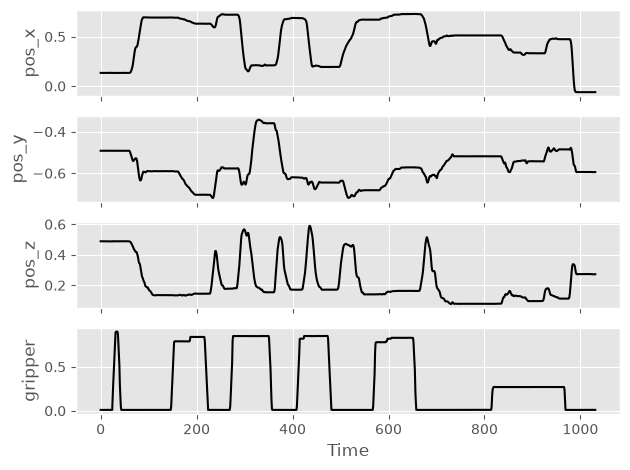

In [90]:
plot_xyzgrip(traj=traj_res, time_type="index", fname="res.png")

In [91]:
np.savetxt("traj_res.out", traj_res.to_numpy())